# Systematic Review
**References:**
* ❌ too old - https://github.com/chandraveshchaudhari/systematic-reviewpy
* ❌ agentic AI - https://github.com/PouriaRouzrokh/LatteReview
* ✅ Uses PubMed API - https://github.com/gijswobben/pymed

**TO-DO**
* ✅ Clean this notebook up
* Run the query on other databases as well
* QC the results from each database, starting with pubmed.
* Once QC'd, merge the results across each database result and process.

**REFERENCES THAT CAUGHT MY EYE**
* https://pubmed.ncbi.nlm.nih.gov/33202965/
* https://pubmed.ncbi.nlm.nih.gov/38389433/

## Environment Setup

In [ ]:
# Import all required packages
from datetime import datetime
from dotenv import load_dotenv
from pathlib import Path
from pymed import PubMed
import json
import os
import pandas as pd
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
import nltk
from nltk.tokenize import sent_tokenize
import plotly.express as px

# Load environment variables
load_dotenv()

# Utility: safe emptiness check for arrays/iterables
def is_empty(obj):
    """Return True if obj is None or has zero length/size; safe for lists, pandas Series, numpy arrays, sparse matrices."""
    if obj is None:
        return True
    # Try length
    try:
        return len(obj) == 0
    except Exception:
        pass
    # Try numpy-like size attribute
    try:
        return getattr(obj, 'size', 0) == 0
    except Exception:
        return False


# Specify Search Strategy

Hack: I used the query builder on https://pubmed.ncbi.nlm.nih.gov/advanced/ to create this




In [ ]:
# Note that the parameters are not required but kindly requested by PubMed Central
# https://www.ncbi.nlm.nih.gov/pmc/tools/developers/
pubmed = PubMed(tool="MyTool", email=os.getenv("PUBMED_EMAIL"))

# This is the bottom-up query that guided the keywords I wanted.
query = '"geospatial analysis" AND "parkinson* disease"' # n = 3

# Execute the query against the API
# Convert to list so the results can be iterated multiple times (not exhausted)
results = list(pubmed.query(query, max_results=100))

## Initial Query Results

### Preview query results as a DataFrame

This cell converts `results` (a list of PubMed article objects) into a pandas DataFrame for quick inspection. It shows the first 10 rows and creates `df_results` for further exploration. If `results` is missing/empty, the preview cell prints a message instead.

In [ ]:
# Preview `results` as a pandas DataFrame
# This cell converts the `results` list (PubMed article objects) into a DataFrame
# and displays a concise preview (first N rows).

if 'results' not in globals() or is_empty(results):
    print("`results` is not defined or empty. Run the query cell above to populate `results`.")
else:
    def _article_to_flat_dict(article):
        # Try to leverage article.toJSON() when available
        try:
            raw = article.toJSON()
            if isinstance(raw, str):
                return json.loads(raw)
            if isinstance(raw, dict):
                return raw
        except Exception:
            pass

        # Fallback: extract common attributes safely
        return {
            "pubmed_id": getattr(article, "pubmed_id", None),
            "title": getattr(article, "title", None),
            "publication_date": str(getattr(article, "publication_date", "") or ""),
            "keywords": getattr(article, "keywords", None),
            "abstract": getattr(article, "abstract", None),
        }

    df_results = pd.json_normalize([_article_to_flat_dict(a) for a in results])


In [ ]:
# Pick nice default preview columns (if present)
preview_cols = [c for c in ["title", "abstract", "publication_date", "keywords"] if c in df_results.columns]

# Make output readable in the notebook
#pd.set_option('display.max_colwidth', 200)
n = 10
print(f"Showing first {min(n, len(df_results))} of {len(df_results)} results (variable: df_results)")
display(df_results[preview_cols].head(n))

Showing first 3 of 3 results (variable: df_results)


,title,abstract,publication_date,keywords
0,Geospatial Analysis of Persons with Movement D...,Movement disorders persons from underserved ar...,2021-09-14,"[Movement Disorders, geography, spatial analys..."
1,Geospatial analysis of individual-based Parkin...,The etiology of Parkinson's disease (PD) remai...,2021-01-22,"[Air pollution, Environment, Epidemiology, Par..."
2,Geospatial Analysis of Environmental Atmospher...,Despite the vast evidence on the environmental...,2020-11-19,"[environment, epidemiology, geospatial, neurod..."


## Refining the Query
I'll use NLP to identify the keywords to expand the initial query on.

In [ ]:
# Combine fields into single text per document
# NOTE: make checks robust against numpy arrays / lists / pandas NA (avoid ambiguous truth values)

def _to_text(row, cols=('title', 'abstract', 'keywords')):
    parts = []
    for c in cols:
        # row might be a dict (to_dict orient='records') or a pandas Series
        if isinstance(row, dict):
            val = row.get(c, '')
        else:
            # Series-like
            val = row.get(c, '') if c in row else ''

        # Handle common NA / empty cases safely (avoid pd.isna() directly in an if)
        if val is None:
            val = ''
        elif isinstance(val, float) and np.isnan(val):
            val = ''
        elif isinstance(val, (list, tuple)):
            # join list-like values
            if len(val) == 0:
                val = ''
            else:
                val = ' '.join(map(str, val))
        elif isinstance(val, (np.ndarray,)):
            # convert numpy arrays to list then join
            if val.size == 0:
                val = ''
            else:
                val = ' '.join(map(str, val.tolist()))
        else:
            # keep whatever string representation
            val = '' if (isinstance(val, float) and np.isnan(val)) else str(val)

        parts.append(val)

    # Only return joined string from non-empty parts
    return ' '.join([p for p in parts if p])

# Small helper to normalize candidate terms when comparing
def _normalize(s):
    s = re.sub(r"[^a-z0-9\s]"," ", s.lower())
    s = re.sub(r"\s+"," ", s).strip()
    return s


In [ ]:
# Combine relevant text columns into a single corpus
try:
    corpus = [_to_text(r) for r in df_results.to_dict(orient='records')]
    print(f"Built corpus with {len(corpus)} documents")
    if not is_empty(corpus):
        print("Sample (first document, first 300 chars):\n", corpus[0][:300])
except Exception as e:
    # Provide a helpful debugging hint rather than failing silently
    raise RuntimeError("Failed to build corpus from df_results — check the data types in your text columns") from e

Built corpus with 3 documents
Sample (first document, first 300 chars):
 Geospatial Analysis of Persons with Movement Disorders Living in Underserved Regions. Movement disorders persons from underserved areas have increased barriers to access tertiary care. There is currently limited data on the geographic and demographic profile of movement disorders persons from unders


In [ ]:
# Parse out current query words/phrases to avoid suggesting exact duplicates
existing_query_terms = set([_normalize(t) for t in re.findall(r"[A-Za-z*]+(?:\s+[A-Za-z*]+)*", query)])

### TF-IDF and N-gram Frequency Calculation
In information retrieval, tf–idf (term frequency–inverse document frequency, TF*IDF, TFIDF, TF–IDF, or Tf–idf) is a measure of importance of a word to a document in a collection or corpus, adjusted for the fact that some words appear more frequently in general.
https://en.wikipedia.org/wiki/Tf%E2%80%93idf

In [ ]:
# TF-IDF over 1..3 grams
tfidf = TfidfVectorizer(ngram_range=(1,3), stop_words='english', max_df=0.9)
X = tfidf.fit_transform(corpus)
feature_names = tfidf.get_feature_names_out()

# Sum TF-IDF across rows to get corpus-level importance
scores = np.asarray(X.sum(axis=0)).ravel()

tfidf_df = pd.DataFrame({'term': feature_names, 'tfidf': scores})
#print(f"Computed TF-IDF for {len(tfidf_df)} terms (1-3 grams)")
#print(tfidf_df.head(10))

### n-gram
An *n*-gram is a sequence of *n* adjacent symbols in a particular order. The symbols may be *n* adjacent letters, syllables, or rarely whole words found in a language dataset; or adjacent phonemes extracted from a speech-recording dataset, or adjacent base pairs extracted from a genome. They are collected from a text corpus or speech corpus. https://en.wikipedia.org/wiki/N-gram

In [ ]:
# Raw frequency counts for same n-grams
cv = CountVectorizer(ngram_range=(1,3), stop_words='english')
Y = cv.fit_transform(corpus)
freqs = np.asarray(Y.sum(axis=0)).ravel()
cv_terms = cv.get_feature_names_out()

freq_df = pd.DataFrame({'term': cv_terms, 'count': freqs})
#print(f"Computed raw counts for {len(freq_df)} terms (1-3 grams)")
#print(freq_df.head(10))

In [ ]:
# Merge the two recommendation signals
cand = tfidf_df.merge(freq_df, on='term', how='outer').fillna(0)

# Add a combined score that balances TF-IDF and frequency
cand['score'] = cand['tfidf'] * 0.7 + (cand['count'] / (cand['count'].max() + 1e-9)) * 0.3

# Add ngram length (for grouping / filtering)
cand['ngram_len'] = cand['term'].str.count(' ') + 1

# Normalize terms for filtering against the query
cand['term_norm'] = cand['term'].apply(_normalize)

# Filter out terms included in the query and short stopwords
cand = cand[~cand['term_norm'].isin(existing_query_terms)]

# Exclude single characters and pure numbers
cand = cand[cand['term'].str.len() > 2]
cand = cand[~cand['term'].str.match(r"^\d+$")]

In [ ]:
# Show top candidates for each n-gram size
top_n = 20
results_unified = cand.sort_values('score', ascending=False).head(top_n)

print(f"Found {len(cand)} candidate terms; showing top {len(results_unified)} overall")

# Display grouped results with helpful columns
display_cols = ['term', 'ngram_len', 'count', 'tfidf', 'score']
print('\nTop candidates (combined score):')
display(results_unified[display_cols].reset_index(drop=True))

# Also show top single-word and multi-word candidates separately
for n in (1,2):
    section = cand[cand['ngram_len']==n].sort_values('score', ascending=False).head(10)
    if not section.empty:
        print(f"\nTop {len(section)} ngram_len={n} candidates:")
        display(section[display_cols].reset_index(drop=True))

# Provide a simple function to return a list of recommended terms to extend the query
def suggest_expansions(n=20, min_count=1):
    s = cand[cand['count'] >= min_count].sort_values('score', ascending=False)
    return list(s['term'].head(n))

Found 1039 candidate terms; showing top 20 overall

Top candidates (combined score):


,term,ngram_len,count,tfidf,score
0,underserved,1,9,0.311687,0.463635
1,neurodegenerative,1,6,0.352000,0.410037
2,spatial,1,7,0.189831,0.323791
3,movement disorders,2,6,0.207791,0.309090
4,movement,1,6,0.207791,0.309090
5,persons,1,6,0.207791,0.309090
6,disorders,1,6,0.207791,0.309090
7,environmental,1,5,0.205719,0.280367
8,prevalence,1,5,0.179144,0.261764
9,population,1,5,0.134423,0.230460



Top 10 ngram_len=1 candidates:


,term,ngram_len,count,tfidf,score
0,underserved,1,9,0.311687,0.463635
1,neurodegenerative,1,6,0.352000,0.410037
2,spatial,1,7,0.189831,0.323791
3,movement,1,6,0.207791,0.309090
4,disorders,1,6,0.207791,0.309090
5,persons,1,6,0.207791,0.309090
6,environmental,1,5,0.205719,0.280367
7,prevalence,1,5,0.179144,0.261764
8,population,1,5,0.134423,0.230460
9,review,1,4,0.160191,0.221225



Top 10 ngram_len=2 candidates:


,term,ngram_len,count,tfidf,score
0,movement disorders,2,6,0.207791,0.309090
1,air pollution,2,4,0.143315,0.209412
2,uf nfind,2,4,0.138527,0.206060
3,environmental atmospheric,2,3,0.176000,0.205018
4,neurodegenerative diseases,2,3,0.176000,0.205018
5,systematic review,2,3,0.176000,0.205018
6,risk factors,2,3,0.116484,0.163357
7,pd prevalence,2,3,0.107486,0.157059
8,spatial dependence,2,3,0.107486,0.157059
9,underserved persons,2,3,0.103896,0.154545


## Visualising the TF-IDF results

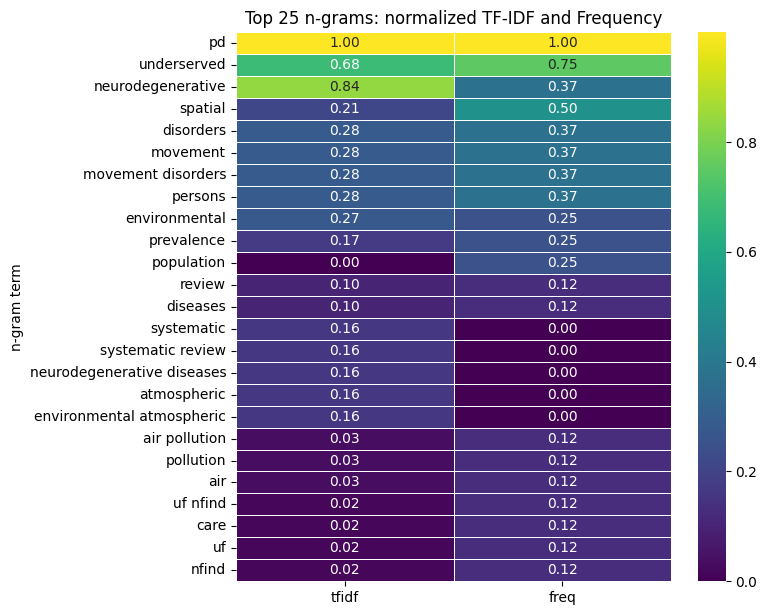

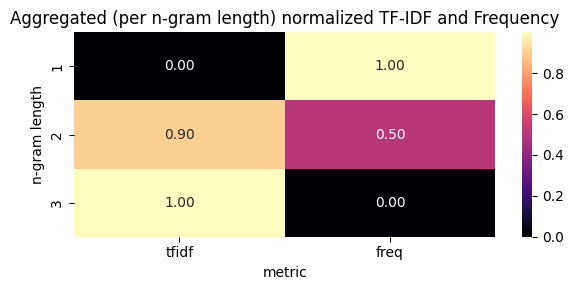

plotly not available or interactive inline mode not set — seaborn plots are shown above.


In [ ]:
# Verify dataframes exist
if 'tfidf_df' not in globals() or 'freq_df' not in globals():
    raise RuntimeError('tfidf_df and/or freq_df not found. Run the TF-IDF / CountVectorizer cells first.')

# Merge tfidf and count into a single dataframe
ngram_df = tfidf_df.merge(freq_df, on='term', how='outer').rename(columns={'count':'freq'})
ngram_df['tfidf'] = ngram_df['tfidf'].fillna(0.0)
ngram_df['freq'] = ngram_df['freq'].fillna(0.0)

# Add ngram length (words)
ngram_df['ngram_len'] = ngram_df['term'].str.count(' ') + 1

# Choose top terms to display
top_n = 25
# Ranking by combined signal: normalize and add
if ngram_df['tfidf'].max() > 0 and ngram_df['freq'].max() > 0:
    tfidf_norm = (ngram_df['tfidf'] - ngram_df['tfidf'].min()) / (ngram_df['tfidf'].max() - ngram_df['tfidf'].min() + 1e-9)
    freq_norm = (ngram_df['freq'] - ngram_df['freq'].min()) / (ngram_df['freq'].max() - ngram_df['freq'].min() + 1e-9)
    ngram_df['combined_score'] = tfidf_norm * 0.6 + freq_norm * 0.4
else:
    ngram_df['combined_score'] = ngram_df['tfidf'] + ngram_df['freq']

# Select top terms
top_terms = ngram_df.sort_values('combined_score', ascending=False).head(top_n).copy()
# Prepare matrix for heatmap: rows=terms, cols=[tfidf, freq]
heat_df = top_terms.set_index('term')[['tfidf', 'freq']]
# Normalize columns for visual parity
heat_norm = heat_df.copy()
heat_norm['tfidf'] = (heat_norm['tfidf'] - heat_norm['tfidf'].min()) / (heat_norm['tfidf'].max() - heat_norm['tfidf'].min() + 1e-9)
heat_norm['freq'] = (heat_norm['freq'] - heat_norm['freq'].min()) / (heat_norm['freq'].max() - heat_norm['freq'].min() + 1e-9)

# Plot seaborn heatmap
plt.figure(figsize=(8, max(6, len(heat_norm) * 0.25)))
sns.heatmap(heat_norm, cmap='viridis', linewidths=0.5, linecolor='white', annot=True, fmt='.2f')
plt.title(f'Top {len(heat_norm)} n-grams: normalized TF-IDF and Frequency')
plt.ylabel('n-gram term')
plt.tight_layout()
plt.show()

# Optional: grouped heatmap by ngram length and metric
pivot_len = ngram_df.groupby(['ngram_len'])[['tfidf','freq']].sum().sort_index()
plt.figure(figsize=(6,3))
sns.heatmap((pivot_len - pivot_len.min())/(pivot_len.max()-pivot_len.min()+1e-9), cmap='magma', annot=True, fmt='.2f')
plt.title('Aggregated (per n-gram length) normalized TF-IDF and Frequency')
plt.xlabel('metric')
plt.ylabel('n-gram length')
plt.tight_layout()
plt.show()

# Optional interactive heatmap using plotly (only if plotly is installed)
try:
    d = heat_norm.reset_index().melt(id_vars='term', var_name='metric', value_name='value')
    fig = px.imshow(heat_norm.values, x=heat_norm.columns, y=heat_norm.index, color_continuous_scale='Viridis')
    fig.update_layout(title=f'Interactive top {len(heat_norm)} n-grams heatmap (norm)')
    fig.show()
except Exception:
    print('plotly not available or interactive inline mode not set — seaborn plots are shown above.')

## Query with new criteria

In [ ]:
# This is the expanded query using the NLP-driven term rankings. n = 6,335
# Adding exclusion criteria based on scope of research question. 
query = '("parkinson* disease" OR "neurodegenerative disease") AND ("geospatial" OR "spatial dependence" OR "spatiotemporal" OR "geographic" OR "environment*" OR "atmospheric") AND ("pollution" OR "chemical" OR "pesticide") NOT ("pathology" OR "treatment" OR "therapy" OR "intervention" OR "physiology" OR "monitoring" OR "biosensor") NOT ("plant" OR "in vitro" OR "animal" OR "molecular" OR "protein" OR "mice") NOT ("parkinson* disease model" OR "respiratory" OR "resistance training" OR "aggression")' # n = 326, 138 in last 5 years

In [ ]:
# Execute the query against the API
# Convert to list so the results can be iterated multiple times (not exhausted)
results = list(pubmed.query(query, max_results=500))
df_results = pd.json_normalize([_article_to_flat_dict(a) for a in results])

# Limit to last 5 years
df_results['publication_date'] = pd.to_datetime(df_results['publication_date'], format='ISO8601')
start_date = '2020-01-01'
df_filtered = df_results[df_results['publication_date'] >= start_date]

# Pick nice default preview columns (if present)
preview_cols = [c for c in ["title", "abstract", "publication_date", "keywords"] if c in df_results.columns]

# Make output readable in the notebook
n = 5
print('Total number of articles:', df_results.shape[0]) # get number of rows
print('Total articles in last 5 years:', df_filtered.shape[0]) # get number of rows after date filter
display(df_filtered[preview_cols].head(n))

Total number of articles: 326
Total articles in last 5 years: 156


,title,abstract,publication_date,keywords
0,Air pollution and disease progression in a Uni...,"Amyotrophic lateral sclerosis (ALS) is a rare,...",2025-11-25,"[ALSFRS-R, Air pollution, Amyotrophic lateral ..."
1,Inhibition of Mitochondrial Complex III Causes...,Environmental factors including chemical expos...,2025-11-24,[]
2,Air pollution and Parkinson's disease: A prosp...,Air pollution has been suggested as a potentia...,2025-11-21,"[Air Pollution, Nitrogen Dioxide, Parkinson’s ..."
3,Do microplastics play a role in the pathogenes...,The widespread presence of microplastics (MPs)...,2025-11-18,"[Alzheimer’s disease, Microplastics, Neuro-pat..."
4,Environmental toxins in neurodegeneration - a ...,As the global incidence of neurodegenerative d...,2025-11-18,"[Air pollution, Alzheimer’s disease, Amyotroph..."


# Cleaning articles

In [ ]:
# Removing duplicates in title
df_filtered = df_filtered.drop_duplicates(subset=['title'])

# Removing if pubmed_id is empty
df_filtered = df_filtered.dropna(subset=['pubmed_id'])

# Remove if doi is missing
df_filtered = df_filtered.dropna(subset=['doi'])

# Preview cleaned df
n = 5
print('Total articles after cleaning:', df_filtered.shape[0]) # get number of rows after cleaning
display(df_filtered[preview_cols].head(n))

Total articles after cleaning: 154


,title,abstract,publication_date,keywords
0,Air pollution and disease progression in a Uni...,"Amyotrophic lateral sclerosis (ALS) is a rare,...",2025-11-25,"[ALSFRS-R, Air pollution, Amyotrophic lateral ..."
1,Inhibition of Mitochondrial Complex III Causes...,Environmental factors including chemical expos...,2025-11-24,[]
2,Air pollution and Parkinson's disease: A prosp...,Air pollution has been suggested as a potentia...,2025-11-21,"[Air Pollution, Nitrogen Dioxide, Parkinson’s ..."
3,Do microplastics play a role in the pathogenes...,The widespread presence of microplastics (MPs)...,2025-11-18,"[Alzheimer’s disease, Microplastics, Neuro-pat..."
4,Environmental toxins in neurodegeneration - a ...,As the global incidence of neurodegenerative d...,2025-11-18,"[Air pollution, Alzheimer’s disease, Amyotroph..."


# Visualising the TF-IDF of the cleaned scrape

In [ ]:
# Compute TF-IDF and n-gram counts from df_filtered (title, abstract, keywords)
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

if 'df_filtered' not in globals():
    try:
        df_filtered = pd.read_csv('pubmed_results_cleaned_2025.csv')
        print('Loaded df_filtered from CSV')
    except Exception:
        raise RuntimeError('`df_filtered` not found — run the cleaning cells first or place pubmed_results_cleaned_2025.csv in the workspace.')

# Compose doc_text_filtered using title, abstract, keywords if available
cols_to_use = ['title', 'abstract', 'keywords']
existent = [c for c in cols_to_use if c in df_filtered.columns.tolist()]
if not existent:
    raise RuntimeError('No columns among title/abstract/keywords present in `df_filtered`.')

# Helper to join fields safely

def _build_doc_text_from_filtered(row):
    parts = []
    for c in ['title', 'abstract', 'keywords']:
        # Support row as dict or pandas Series
        if isinstance(row, dict):
            has_key = c in row
            val = row.get(c, '')
        else:
            # Series-like
            has_key = c in row
            val = row[c] if has_key else ''

        if not has_key:
            continue

        # Robust empty / NA checks (avoid using pd.notna(...) directly in `if`)
        if val is None:
            continue
        if isinstance(val, float) and np.isnan(val):
            continue

        # If list/tuple, join
        if isinstance(val, (list, tuple)):
            if len(val) == 0:
                continue
            val = ' '.join(map(str, val))

        # If numpy array, convert then join
        if isinstance(val, np.ndarray):
            if val.size == 0:
                continue
            val = ' '.join(map(str, val.tolist()))

        # Finally coerce to string and append
        s = str(val).strip()
        if s:
            parts.append(s)

    return '\n'.join(parts)

# Create / refresh doc_text_filtered
if 'doc_text_filtered' not in df_filtered.columns.tolist():
    df_filtered = df_filtered.copy()
    df_filtered['doc_text_filtered'] = df_filtered.apply(lambda r: _build_doc_text_from_filtered(r.to_dict()), axis=1)
else:
    print('doc_text_filtered exists — reusing')

print('Prepared doc_text_filtered for', len(df_filtered), 'documents')

# Vectorizers parameters
ngram_range = (1, 3)
max_df = 0.9

# TF-IDF vectoriser over the filtered documents
print('Fitting TF-IDF vectorizer on df_filtered...')
tfidf_vec_f = TfidfVectorizer(ngram_range=ngram_range, stop_words='english', max_df=max_df)
X_filtered = tfidf_vec_f.fit_transform(df_filtered['doc_text_filtered'].astype(str))
feature_names_filtered = tfidf_vec_f.get_feature_names_out()

# Sum TF-IDF across documents (corpus-level importance)
tfidf_scores = np.asarray(X_filtered.sum(axis=0)).ravel()

# Build corpus-level tfidf_df_filtered
tfidf_df_filtered = pd.DataFrame({'term': feature_names_filtered, 'tfidf': tfidf_scores})

# CountVectorizer for raw frequency counts
print('Fitting CountVectorizer on df_filtered...')
count_vec_f = CountVectorizer(ngram_range=ngram_range, stop_words='english')
Y_filtered = count_vec_f.fit_transform(df_filtered['doc_text_filtered'].astype(str))
cv_terms_filtered = count_vec_f.get_feature_names_out()
freqs_filtered = np.asarray(Y_filtered.sum(axis=0)).ravel()

freq_df_filtered = pd.DataFrame({'term': cv_terms_filtered, 'count': freqs_filtered})

# Merge tfidf and frequency into a single frame
ngram_df_filtered = tfidf_df_filtered.merge(freq_df_filtered, on='term', how='outer').fillna(0)
ngram_df_filtered['ngram_len'] = ngram_df_filtered['term'].str.count(' ') + 1

print('Computed TF-IDF and frequency for', len(ngram_df_filtered), 'unique n-grams')

# Quick preview of top 30 terms by TF-IDF
preview_top = 30
display(ngram_df_filtered.sort_values('tfidf', ascending=False).head(preview_top))

# Persist objects for the next visualisation cell
globals().update({'X_filtered': X_filtered, 'feature_names_filtered': feature_names_filtered, 'ngram_df_filtered': ngram_df_filtered, 'tfidf_df_filtered': tfidf_df_filtered, 'freq_df_filtered': freq_df_filtered})

print('\nDone — TF-IDF and n-grams computed for df_filtered. Next: run the heatmap cell to visualise TF-IDF across top terms and documents.')

Prepared doc_text_filtered for 154 documents
Fitting TF-IDF vectorizer on df_filtered...
Fitting CountVectorizer on df_filtered...
Computed TF-IDF and frequency for 35838 unique n-grams
Computed TF-IDF and frequency for 35838 unique n-grams


,term,tfidf,count,ngram_len
24519,pd,5.438193,329,1
13453,exposure,4.274806,308,1
3166,air,4.228021,199,1
26105,pollution,3.851210,195,1
23832,parkinson,3.751006,267,1
3194,air pollution,3.668130,170,2
23843,parkinson disease,3.428601,238,2
29643,risk,3.147270,198,1
9449,dementia,2.680632,125,1
32108,study,2.538238,168,1



Done — TF-IDF and n-grams computed for df_filtered. Next: run the heatmap cell to visualise TF-IDF across top terms and documents.


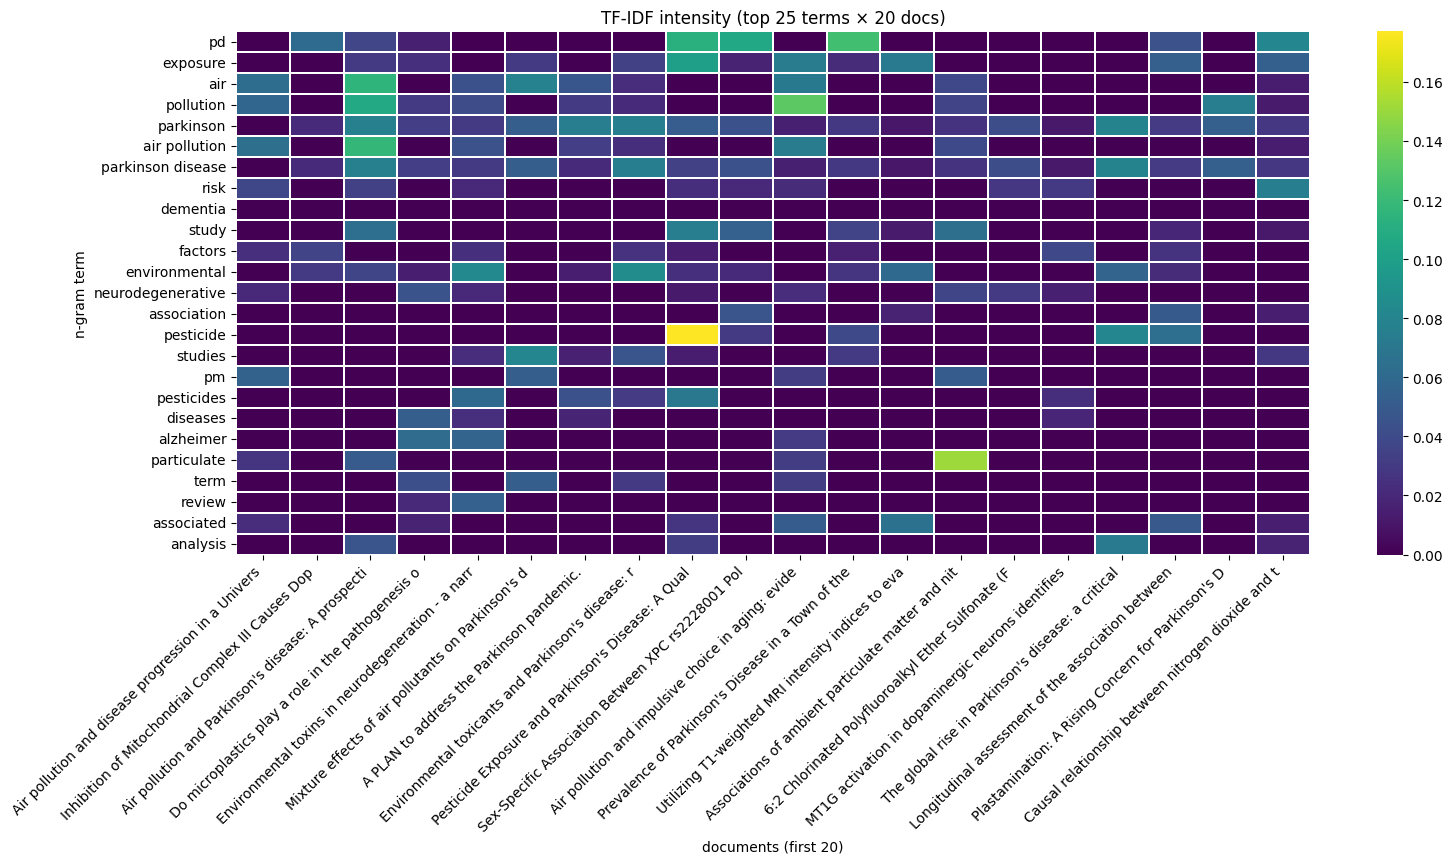

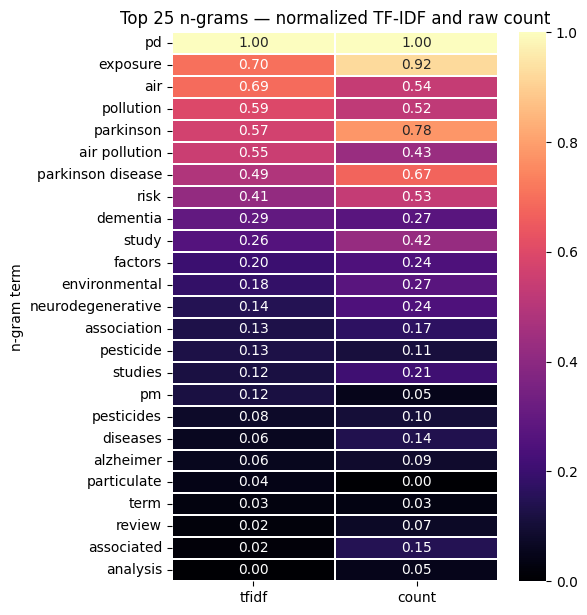

Plotly interactive heatmap not shown (plotly may be missing or not running inline).


In [ ]:
# Visualise TF-IDF: term × document heatmap and top-term heatmap
# Ensure we have the expected objects
if 'X_filtered' not in globals() or 'feature_names_filtered' not in globals() or 'ngram_df_filtered' not in globals():
    raise RuntimeError('Required objects for visualization not found. Run the TF-IDF/n-gram computation cell first.')

# Parameters
top_n_terms = 25    # number of top terms to visualise
max_docs = 20       # maximum number of documents (columns) to show — adjust for readability

# Pick the top terms by corpus TF-IDF
top_terms = ngram_df_filtered.sort_values('tfidf', ascending=False).head(top_n_terms)['term'].tolist()
# Map to indices in feature_names_filtered
term_to_idx = {t: i for i, t in enumerate(feature_names_filtered)}
selected_indices = [term_to_idx[t] for t in top_terms if t in term_to_idx]

# Build term-document TF-IDF matrix (terms x docs) using X_filtered (docs x terms)
# We'll limit to first max_docs documents for readability; you can change to a custom sample if needed
n_docs = X_filtered.shape[0]
if n_docs == 0:
    raise RuntimeError('No documents (rows) found in X_filtered')

doc_indices = list(range(min(n_docs, max_docs)))

# extract slice
mat = X_filtered[doc_indices, :][:, selected_indices].toarray().T  # terms x docs

# Build labels
term_labels = [feature_names_filtered[i] for i in selected_indices]
doc_titles = df_filtered.iloc[doc_indices]['title'].fillna('').astype(str).apply(lambda s: s[:50]).tolist()

# Plot heatmap of term-document TF-IDF
plt.figure(figsize=(max(10, len(doc_titles)*0.8), max(6, len(term_labels)*0.35)))
sns.heatmap(mat, yticklabels=term_labels, xticklabels=doc_titles, cmap='viridis', linewidths=0.3)
plt.title(f'TF-IDF intensity (top {len(term_labels)} terms × {len(doc_titles)} docs)')
plt.xlabel('documents (first {})'.format(len(doc_titles)))
plt.ylabel('n-gram term')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Second plot: normalized corpus-level TF-IDF heatmap (term × metric scalar)
# Select top_terms stats from ngram_df_filtered
top_stats = ngram_df_filtered.set_index('term').loc[top_terms][['tfidf','count']]
# Normalize for display
norm_stats = top_stats.copy()
norm_stats['tfidf'] = (norm_stats['tfidf'] - norm_stats['tfidf'].min()) / (norm_stats['tfidf'].max() - norm_stats['tfidf'].min() + 1e-9)
norm_stats['count'] = (norm_stats['count'] - norm_stats['count'].min()) / (norm_stats['count'].max() - norm_stats['count'].min() + 1e-9)

plt.figure(figsize=(6, max(6, len(norm_stats)*0.25)))
sns.heatmap(norm_stats, cmap='magma', annot=True, fmt='.2f', linewidths=0.2)
plt.title(f'Top {len(norm_stats)} n-grams — normalized TF-IDF and raw count')
plt.ylabel('n-gram term')
plt.tight_layout()
plt.show()

# Optional interactive display with plotly (if available)
try:
    import plotly.express as px
    import pandas as pd
    fig = px.imshow(mat, x=doc_titles, y=term_labels, color_continuous_scale='Viridis')
    fig.update_layout(title=f'Interactive TF-IDF (top {len(term_labels)} terms × {len(doc_titles)} docs)', xaxis={'tickangle':-45})
    fig.show()
except Exception:
    print('Plotly interactive heatmap not shown (plotly may be missing or not running inline).')

# Export Query Results

In [ ]:
# Export cleaned results to CSV
output_csv_path = Path("pubmed_results_cleaned_2025.csv")
df_filtered.to_csv(output_csv_path, index=False)
print(f"Exported cleaned results to {output_csv_path.resolve()}")

Exported cleaned results to /mnt/c/Users/ReginaChua/Desktop/sysrev/pubmed_results_cleaned_2025.csv
